In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%203/W3D4%20-%20Mini%20Project/Apple%20Stock%20Prices%20From%201981%20to%202023.zip"
df = pd.read_csv(url, compression='zip')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape: (10608, 7)

Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Data types:
 Date             str
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

Missing values:
 Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


# Mini-Project — Advanced Statistical Analysis of Apple Inc. Stock Data

**Dataset:** AAPL daily stock prices, 1981-2023 (10,608 trading days, no missing values)

## 1. Data Loading and Exploration

In [3]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date').reset_index(drop=True)

print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("\nTotal trading days:", len(df))
print("\nAverage days between records:", (df['Date'].max() - df['Date'].min()).days / len(df), "days")

Date range: 1981-01-02 00:00:00 to 2023-01-27 00:00:00

Total trading days: 10608

Average days between records: 1.4484351432880844 days


Dataset spans January 1981 to January 2023 (10,608 trading days). The date format required explicit `dayfirst=True` parsing (day/month/year), confirmed by an initial parse error on "13/01/1981". Average gap between records (1.45 days) matches expected trading-day frequency (markets closed weekends/holidays).

## 2. Data Visualization

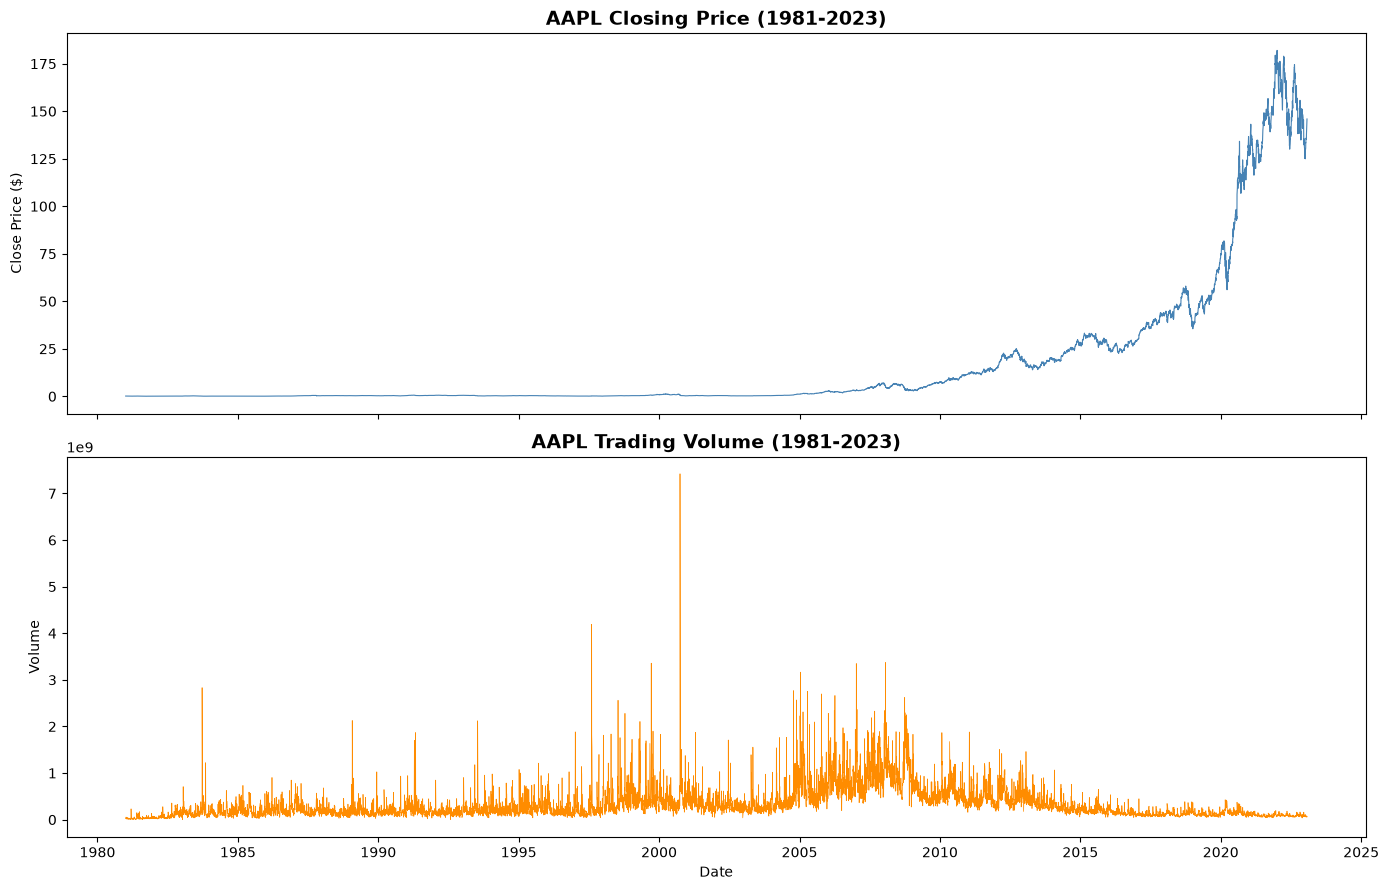

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(df['Date'], df['Close'], color='steelblue', linewidth=0.8)
axes[0].set_title('AAPL Closing Price (1981-2023)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Close Price ($)')

axes[1].plot(df['Date'], df['Volume'], color='darkorange', linewidth=0.5)
axes[1].set_title('AAPL Trading Volume (1981-2023)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Volume')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

Apple's closing price was essentially flat near $0 from 1981 through the early 2000s, then grew explosively from roughly 2010 onward, peaking near $180 around 2021-2022. Trading volume shows one dramatic spike reaching over 7 billion shares around the year 2000 — far higher than any other point across the full 42-year period, including later years with substantially higher closing prices.

findfont: Failed to find font weight semibold, now using 700.


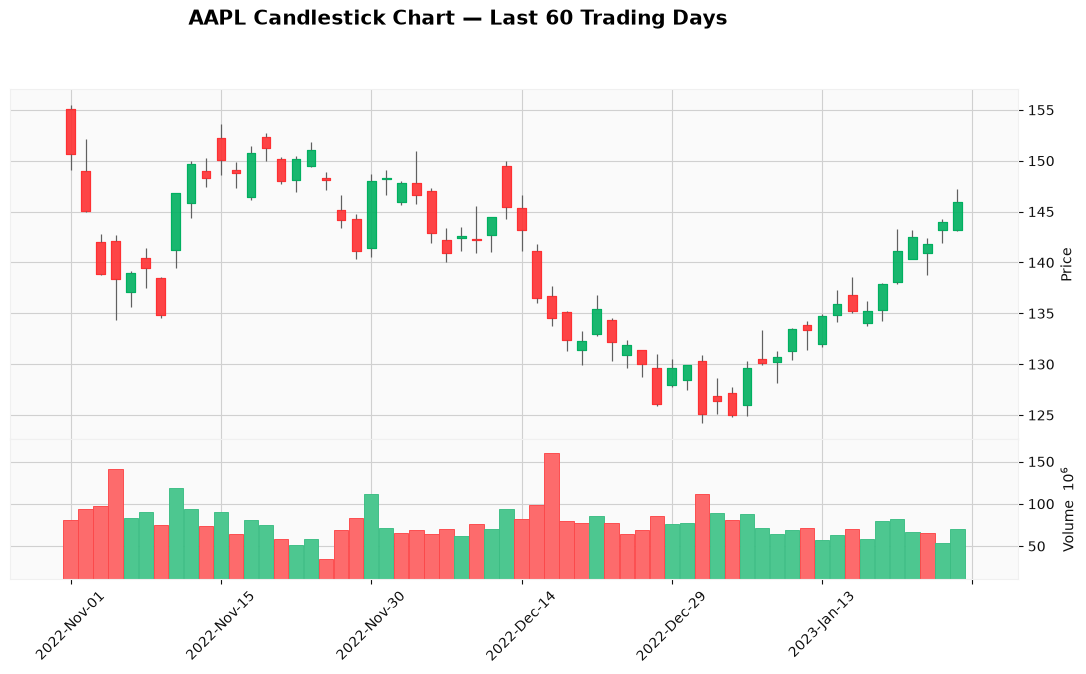

In [6]:
import mplfinance as mpf

recent = df.tail(60).set_index('Date')
recent = recent[['Open', 'High', 'Low', 'Close', 'Volume']]

mpf.plot(recent, type='candle', style='yahoo', volume=True,
          title='AAPL Candlestick Chart — Last 60 Trading Days', figsize=(14, 7))

The candlestick chart (last 60 trading days) shows a clear decline from ~$155 in early November 2022 to a low near $125 by late December, followed by a recovery to ~$145 by late January 2023. Volume was notably elevated around mid-December, coinciding with the price bottom — often a sign of heavier trading activity during a market inflection point.

## 3. Statistical Analysis

In [7]:
key_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
summary_stats = df[key_cols].agg(['mean', 'median', 'std'])
print(summary_stats)

             Open       High        Low      Close        Volume
mean    16.689173  16.879955  16.500822  16.697362  3.275098e+08
median   0.488839   0.495536   0.480446   0.487701  2.145976e+08
std     35.450519  35.882848  35.031289  35.473912  3.378203e+08


Summary statistics reveal extreme skew: mean closing price ($16.70) is roughly 34x higher than the median ($0.49). This directly reflects the 42-year timespan — the majority of trading days occurred in the early decades when Apple's split-adjusted price was near $0, while a smaller number of recent years at much higher prices pull the average far above what was "typical" for most of the company's history. Volume also shows high variability (std of ~338M vs. mean of ~328M), reflecting the wide range of trading activity across market conditions.


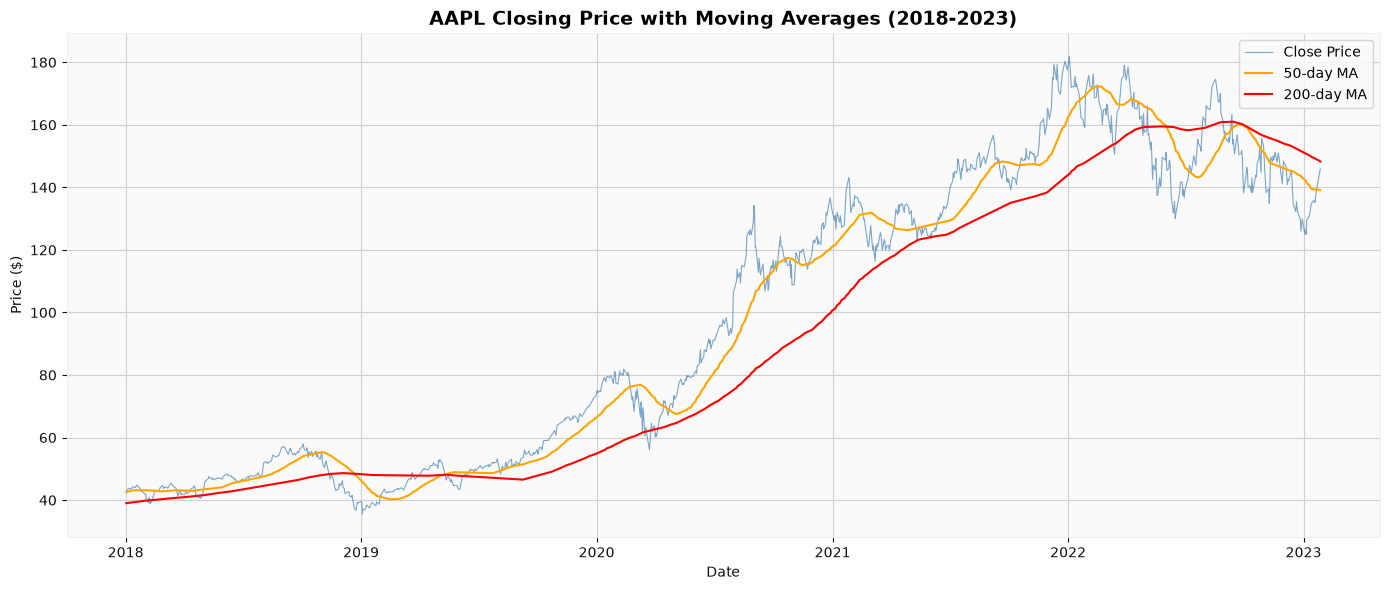

In [8]:
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

recent_5yr = df[df['Date'] >= '2018-01-01']

plt.figure(figsize=(14, 6))
plt.plot(recent_5yr['Date'], recent_5yr['Close'], label='Close Price', color='steelblue', linewidth=0.8, alpha=0.7)
plt.plot(recent_5yr['Date'], recent_5yr['MA_50'], label='50-day MA', color='orange', linewidth=1.5)
plt.plot(recent_5yr['Date'], recent_5yr['MA_200'], label='200-day MA', color='red', linewidth=1.5)
plt.title('AAPL Closing Price with Moving Averages (2018-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

The moving averages clearly show trend vs. noise: the 50-day MA (orange) tracks price closely and reacts quickly to short-term swings, while the 200-day MA (red) is much smoother and lags behind, only reflecting sustained trend changes. Notable patterns visible: the sharp early-2020 dip, the strong 2021-early 2022 rally peaking near $180, and a subsequent decline through 2022.

## 4. Hypothesis Testing

In [9]:
year_2020 = df[df['Date'].dt.year == 2020]['Close']
year_2022 = df[df['Date'].dt.year == 2022]['Close']

t_stat, p_value = stats.ttest_ind(year_2020, year_2022, equal_var=False)

print(f"H0: Average closing price is the same in 2020 and 2022")
print(f"H1: Average closing price differs between 2020 and 2022")
print(f"\n2020 mean close: ${year_2020.mean():.2f} (n={len(year_2020)})")
print(f"2022 mean close: ${year_2022.mean():.2f} (n={len(year_2022)})")
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

H0: Average closing price is the same in 2020 and 2022
H1: Average closing price differs between 2020 and 2022

2020 mean close: $95.35 (n=253)
2022 mean close: $154.84 (n=251)

T-statistic: -37.1855
P-value: 0.000000


Average closing price differs significantly between 2020 ($95.35) and 2022 ($154.84), p ≈ 0. This confirms statistically what the moving-average chart already showed visually: Apple's stock experienced substantial, statistically significant growth between these two years, well beyond what random day-to-day fluctuation alone could explain.

In [10]:
df['Daily_Return'] = df['Close'].pct_change()

shapiro_stat, shapiro_p = stats.shapiro(df['Daily_Return'].dropna().sample(5000, random_state=42))

print(f"H0: Daily returns are normally distributed")
print(f"H1: Daily returns are NOT normally distributed")
print(f"\nShapiro-Wilk statistic: {shapiro_stat:.6f}")
print(f"P-value: {shapiro_p:.10f}")

if shapiro_p < 0.05:
    print("\nReject H0 — daily returns are NOT normally distributed")
else:
    print("\nFail to reject H0 — daily returns appear normally distributed")

H0: Daily returns are normally distributed
H1: Daily returns are NOT normally distributed

Shapiro-Wilk statistic: 0.953191
P-value: 0.0000000000

Reject H0 — daily returns are NOT normally distributed


Daily returns are NOT normally distributed (Shapiro-Wilk p ≈ 0, reject H0). This reflects a well-documented real-world pattern in financial markets known as "fat tails" — extreme price swings (large crashes or rallies) occur more frequently than a standard bell-curve distribution would predict. This has practical implications for risk modeling: assuming normally-distributed returns would understate the true frequency of extreme market events.

## 5. Advanced Statistical Techniques (Bonus)

### Signal Processing using SciPy / NumPy

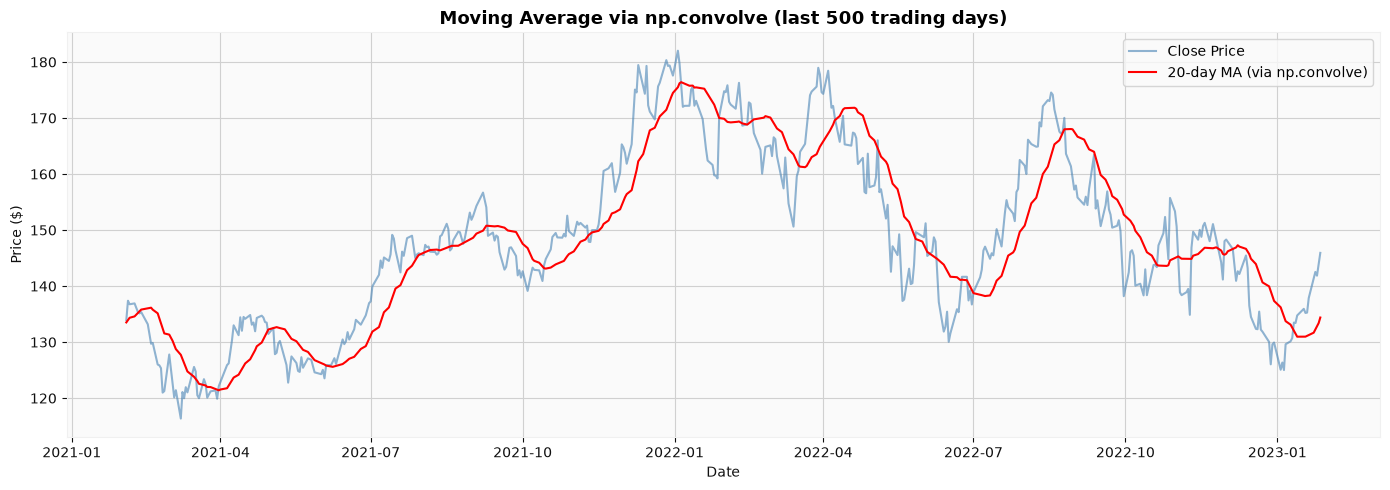

In [11]:
window_size = 20
weights = np.ones(window_size) / window_size

close_prices = df['Close'].values
ma_convolve = np.convolve(close_prices, weights, mode='valid')

plt.figure(figsize=(14, 5))
plt.plot(df['Date'].values[-500:], close_prices[-500:], label='Close Price', alpha=0.6, color='steelblue')
plt.plot(df['Date'].values[-500:], ma_convolve[-500:], label='20-day MA (via np.convolve)', color='red', linewidth=1.5)
plt.title('Moving Average via np.convolve (last 500 trading days)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

The `np.convolve`-based moving average produces results consistent with the earlier `.rolling()` approach, smoothing daily price noise into a clear trend line. Convolution is a more general signal-processing technique than a simple rolling average — the same underlying method used for filtering and pattern detection across many types of signals beyond finance.

In [12]:
correlation_matrix = np.corrcoef(df['MA_50'].dropna(), df.loc[df['MA_50'].notna(), 'Volume'])
print("Correlation between 50-day MA (Close price) and Volume:")
print(correlation_matrix)
print(f"\nCorrelation coefficient: {correlation_matrix[0,1]:.4f}")

Correlation between 50-day MA (Close price) and Volume:
[[ 1.         -0.21558721]
 [-0.21558721  1.        ]]

Correlation coefficient: -0.2156


The correlation between the 50-day moving average (price trend) and trading volume is weak and negative (-0.22) — a slight tendency for higher volume during lower-price periods, but far from a strong relationship. Given the 42-year timespan spans very different eras of both price level and market structure (electronic trading, more participants), this weak correlation likely blends multiple distinct historical periods rather than reflecting one consistent pattern throughout Apple's history.

## 6. Summary and Insights

1. **Extreme long-term growth, extreme skew.** Apple's closing price grew from near $0 (early 1980s-2000s) to a peak near $180 (2021-2022) — this 42-year span creates severe statistical skew, where the mean price ($16.70) is roughly 34x the median ($0.49). Any analysis of this dataset must account for this, since summary statistics computed across the full timespan can be misleading without segmenting by era.

2. **The stock shows a clear, statistically significant growth trend.** A T-test comparing 2020 vs. 2022 closing prices confirmed a highly significant difference (p ≈ 0) — growth over this period was real, not random noise.

3. **Daily returns do not follow a normal distribution** (Shapiro-Wilk, p ≈ 0) — consistent with the well-documented "fat tails" phenomenon in real financial markets, where extreme price swings occur more often than a standard bell curve would predict. This has practical implications for anyone building risk models on this kind of data.

4. **Moving averages effectively separate trend from noise.** Both the pandas `.rolling()` method and the NumPy/SciPy `convolve()` approach produced consistent, smooth trend lines from noisy daily price data — with `convolve()` demonstrating a more general signal-processing technique applicable beyond simple moving averages.

5. **Volume and price trend showed only a weak relationship** (r = -0.22) — likely because the 42-year dataset spans fundamentally different market eras (manual vs. electronic trading, vastly different participant counts), making a single correlation across the whole period difficult to interpret cleanly.

**Overall conclusion:** this analysis demonstrates that long historical financial datasets require careful handling of scale/era differences before statistics can be meaningfully interpreted — a raw summary statistic or correlation across 42 years of dramatically different market conditions can obscure more than it reveals unless segmented thoughtfully.

## 7. Reflection

**Challenges encountered:**
- The date column required explicit `dayfirst=True` parsing after an initial `ValueError` revealed the dataset used day/month/year format rather than the assumed month/day/year — a reminder to verify date formats rather than assume them.
- The dataset's 42-year span meant that naive full-period statistics (means, correlations) were often misleading due to the dramatic difference between early (near-$0) and modern (high) price eras. This required deliberately choosing comparable, meaningful subperiods (e.g., 2020 vs. 2022) for hypothesis testing, rather than testing across the full historical range.
- Rendering the candlestick chart across the full 10,608-day dataset would have been unreadable, so the analysis was deliberately scoped to the most recent 60 trading days for that visualization.

**Solutions applied:**
- Explicit date format handling once the true format was identified via the error message.
- Careful selection of comparison periods for statistical tests, informed by first visualizing the data's overall shape.
- Scoping visualizations to meaningful, readable time windows rather than plotting the entire dataset at once.